In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns
import statsmodels.api as sm
from difflib import get_close_matches
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score


In [46]:
standings = pd.read_csv("futball_21_25.csv")

sofifa = pd.read_csv("sofifa.csv")

In [47]:
df = standings  

plt.figure(figsize=(12, 8), dpi=1000)
plt.suptitle("Distribution of Team Performance Metrics", fontsize=16, fontweight="bold")

# 1. Points
ax1 = plt.subplot(2, 2, 1)
ax1.hist(df["points"], bins=20, color="skyblue", edgecolor="black")
ax1.set_title("Points Distribution")
ax1.set_xlabel("Points")
ax1.set_ylabel("Frequency")

# 2. Wins
ax2 = plt.subplot(2, 2, 2)
ax2.hist(df["wins"], bins=20, color="lightgreen", edgecolor="black")
ax2.set_title("Wins Distribution")
ax2.set_xlabel("Wins")
ax2.set_ylabel("Frequency")

# 3. Goal Difference
ax3 = plt.subplot(2, 2, 3)
ax3.hist(df["goal_diff"], bins=25, color="lightcoral", edgecolor="black")
ax3.set_title("Goal Difference Distribution")
ax3.set_xlabel("Goal Difference")
ax3.set_ylabel("Frequency")

# 4. Losses
ax4 = plt.subplot(2, 2, 4)
ax4.hist(df["losses"], bins=20, color="lightpink", edgecolor="black")
ax4.set_title("Losses Distribution")
ax4.set_xlabel("Losses")
ax4.set_ylabel("Frequency")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [48]:

pd.options.display.float_format = '{:,.2f}'.format

numerical_cols = standings.select_dtypes(include=[np.number]).columns.tolist()

summary_stats = []
for col in numerical_cols:
    summary_stats.append({
        'Feature': col,
        'Mean': standings[col].mean(),
        'Min': standings[col].min(),
        'Max': standings[col].max(),
        'Std': standings[col].std(),
        'Median': standings[col].median(),
        'Range': standings[col].max() - standings[col].min()
    })

summary_df = pd.DataFrame(summary_stats)

summary_df


,Feature,Mean,Min,Max,Std,Median,Range
0,Unnamed: 0,221.49,0,527,161.86,187.50,527
1,season,"2,022.99",2021,2025,1.42,"2,023.00",4
2,played,31.79,10,38,10.38,38.00,28
3,wins,11.86,0,29,6.71,11.00,29
4,draws,8.06,0,19,3.74,8.00,19
5,losses,11.86,0,30,6.34,12.00,30
6,points,43.62,2,95,21.08,42.00,93
7,goal_diff,0.00,-69,73,23.71,-2.00,142


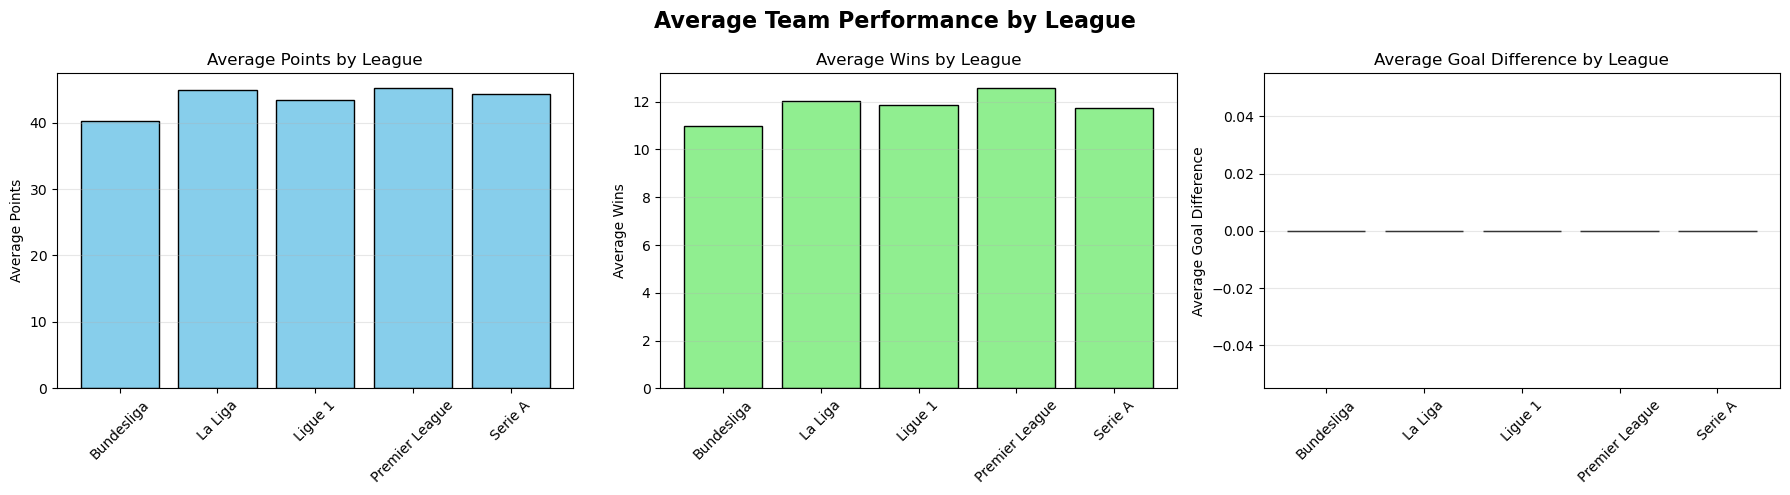

                points  wins  goal_diff
league                                 
Bundesliga       40.17 10.99       0.00
La Liga          44.85 12.05       0.00
Ligue 1          43.33 11.88       0.00
Premier League   45.16 12.56       0.00
Serie A          44.24 11.74       0.00


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Average Team Performance by League', fontsize=16, fontweight='bold')

league_stats = standings.groupby('league').agg({
    'points': 'mean',
    'wins': 'mean',
    'goal_diff': 'mean'
}).round(2)

leagues = league_stats.index

axes[0].bar(leagues, league_stats['points'], color='skyblue', edgecolor='black')
axes[0].set_title('Average Points by League')
axes[0].set_ylabel('Average Points')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(leagues, league_stats['wins'], color='lightgreen', edgecolor='black')
axes[1].set_title('Average Wins by League')
axes[1].set_ylabel('Average Wins')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(leagues, league_stats['goal_diff'], color='lightcoral', edgecolor='black')
axes[2].set_title('Average Goal Difference by League')
axes[2].set_ylabel('Average Goal Difference')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(league_stats)


### Distribution of FIFA Team Attribute Components

We visualize the distribution of key FIFA summary attributes across all players to understand how defending, mentality, movement, and skill are distributed in the underlying ratings dataset.


In [50]:
attrs = ["Total defending", "Total mentality", "Total movement", "Total skill"]

plt.figure(figsize=(12, 8), dpi=1000)

for i, col in enumerate(attrs, 1):
    ax = plt.subplot(2, 2, i)
    sns.histplot(
        sofifa[col].dropna(),
        bins=40,
        kde=True,
        stat="count",
        color="steelblue",
        edgecolor="none",
        alpha=0.5
    )
    ax.set_title(col, fontsize=16, fontweight="bold", pad=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.set_facecolor("white")
    ax.grid(axis="y", alpha=0.2)
    ax.set_title(col, fontsize=16, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.set_title(col, fontsize=16, fontweight="bold")

plt.suptitle("Histogram and Density of FIFA Attribute Components", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### More EDA

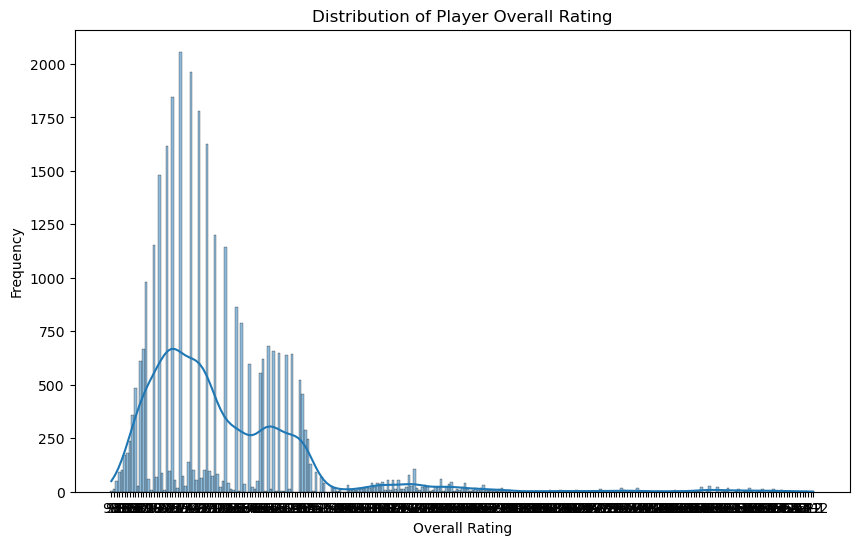

In [51]:
# Dist of Overall rating
plt.figure(figsize=(10, 6))
sns.histplot(sofifa['Overall rating'], bins=30, kde=True)
plt.title('Distribution of Player Overall Rating')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()

#### Fixing Team Mapping

In [52]:
def extract_team(team_contract):
    """Get team name from 'Team & Contract' (before newline)."""
    if isinstance(team_contract, str):
        return team_contract.split("\n")[0].strip()
    return None

sofifa["team_name"] = sofifa["Team & Contract"].apply(extract_team)


# Pre-processing
def extract_team(team_contract):
    if isinstance(team_contract, str):
        return team_contract.split("\n")[0].strip()
    return None
sofifa["team_name"] = sofifa["Team & Contract"].apply(extract_team)

def normalize_team_name(name):
    if not isinstance(name, str): return None

    s = name.lower()
    s = s.replace("-", " ").replace(".", " ")
    s = re.sub(r"\s+", " ", s).strip()
    
    manual_map = {
        "1899 hoffenheim": "tsg 1899 hoffenheim",
        "1 fc union berlin": "1 union berlin",
        "ac ajaccio": "ajaccio",
        "ac monza": "monza",
        "ac pisa 1909": "pisa",
        "acf fiorentina": "fiorentina",
        "ajaccio": "ajaccio",
        "alaves": "deportivo alavés",
        "almeria": "ud almería",
        "angers": "angers sco",
        "arminia bielefeld": "dsc arminia bielefeld",
        "as roma": "roma",
        "atalanta bc": "atalanta",
        "atletico de madrid": "atlético madrid",
        "atletico madrid": "atlético madrid",
        "atlético de madrid": "atlético madrid",
        "auxerre": "aj auxerre",
        "bayer leverkusen": "bayer 04 leverkusen",
        "bayern munich": "bayern münchen",
        "bologna 1909": "bologna",
        "bordeaux": "girondins de bordeaux",
        "borussia monchengladbach": "borussia mönchengladbach",
        "bournemouth": "afc bournemouth",
        "brighton": "brighton & hove albion",
        "cadiz": "cádiz",
        "cagliari calcio": "cagliari",
        "celta vigo": "rc celta",
        "clermont foot": "clermont foot 63",
        "como 1907": "como",
        "espanyol": "rcd espanyol",
        "frosinone calcio": "frosinone",
        "fsv mainz 05": "1 fsv mainz 05",
        "hertha berlin": "hertha bsc",
        "inter milan": "inter",
        "internazionale milano": "inter",
        "koln": "1 köln",
        "1 fc koln": "1 köln",
        "leeds": "leeds united",
        "leicester": "leicester city",
        "lens": "rc lens",
        "levante": "levante ud",
        "lille": "lille osc",
        "luton town": "luton town",
        "lyon": "olympique lyonnais",
        "mallorca": "rcd mallorca",
        "marseille": "olympique de marseille",
        "monaco": "as monaco",
        "montpellier": "montpellier hsc",
        "newcastle": "newcastle united",
        "nice": "ogc nice",
        "norwich": "norwich city",
        "osasuna": "ca osasuna",
        "parma calcio 1913": "parma",
        "racing de lens": "rc lens",
        "rayo vallecano de madrid": "rayo vallecano",
        "rc celta de vigo": "rc celta",
        "rcd espanyol de barcelona": "rcd espanyol",
        "real betis": "real betis balompié",
        "real sociedad de fútbol": "real sociedad",
        "reims": "stade de reims",
        "rennes": "stade rennais",
        "saint etienne": "as saint étienne",
        "salernitana": "us salernitana 1919",
        "spvgg greuther furth": "spvgg greuther fürth",
        "ss lazio": "lazio",
        "ssc napoli": "napoli",
        "st pauli 1910": "st pauli",
        "stade rennais 1901": "stade rennais",
        "strasbourg": "rc strasbourg alsace",
        "sunderland afc": "sunderland",
        "tottenham": "tottenham hotspur",
        "udinese calcio": "udinese",
        "union berlin": "1 fc union berlin",
        "us cremonese": "cremonese",
        "us lecce": "lecce",
        "us sassuolo calcio": "sassuolo",
        "valladolid": "real valladolid",
        "verona": "hellas verona",
        "vfl bochum": "vfl bochum 1848",
        "werder bremen": "sv werder bremen",
        "west ham": "west ham united",
        "wolves": "wolverhampton wanderers"
    }

    if s in manual_map: return manual_map[s]

    s = s.replace("-", " ").replace(".", " ")
    for tok in ["fc", "cf", "club", "football club", "cf.", "fc.", "c.f.", "f.c."]:
        s = re.sub(rf"\b{tok}\b", " ", s)
    s = s.replace("manchester utd", "manchester united")
    s = re.sub(r"\s+", " ", s).strip()
    final_map = {
        "1 union berlin": "1 union berlin",  
        "1 fc union berlin": "1 union berlin", 
        "ajaccio": "ajaccio",
        "ac ajaccio": "ajaccio",
        "atlético de madrid": "atlético madrid",
        "bologna 1909": "bologna",
        "internazionale milano": "inter",
        "koln": "1 köln",
        "1 köln": "1 köln",
        "luton town": "luton town",
        "racing de lens": "rc lens",
        "st pauli 1910": "st pauli",
        "st pauli": "st pauli",
        "stade rennais 1901": "stade rennais",
        "stade rennais": "stade rennais"
    }
    
    if s in final_map:
        return final_map[s]
    return s

standings["team_name_clean"] = standings["team_name"].apply(normalize_team_name)
sofifa["team_name_clean"] = sofifa["team_name"].apply(normalize_team_name)

st_teams = set(standings["team_name_clean"].unique())
fifa_teams = set(sofifa["team_name_clean"].unique())
missing = sorted(list(st_teams - fifa_teams))

print(f"Remaining Mismatched Teams ({len(missing)}):")
for t in missing:
    print(f"- {t}")

print("\n--- Potential Matches ---")
for t in missing:
    matches = get_close_matches(t, list(fifa_teams), n=1, cutoff=0.6)
    if matches:
        print(f"'{t}'  might be  '{matches[0]}'")


Remaining Mismatched Teams (3):
- 1 fc union berlin
- ajaccio
- luton town

--- Potential Matches ---
'1 fc union berlin'  might be  '1 union berlin'


In [53]:
sofifa["Overall rating"] = pd.to_numeric(sofifa["Overall rating"], errors="coerce")
sofifa = sofifa.dropna(subset=["Overall rating"])

def extract_fifa_number(edition):
    """'FIFA 15' -> 15 as int."""
    if isinstance(edition, str):
        parts = edition.split()
        try:
            return int(parts[-1])
        except ValueError:
            return None
    return None

sofifa["fifa_number"] = sofifa["Edition"].apply(extract_fifa_number)


def fifa_to_season_year(fifa_number):
    """
    Map FIFA edition to approximate season year.
    Example: FIFA 22 -> 2021, FIFA 23 -> 2022, etc.
    Adjust if your project defines this differently.
    """
    if pd.isna(fifa_number):
        return None
    return 2000 + fifa_number - 1

sofifa["season"] = sofifa["fifa_number"].apply(fifa_to_season_year)



def parse_euro(s):
    if not isinstance(s, str):
        return np.nan
    s = s.replace("€", "").strip()
    if s.endswith("M"):
        return float(s[:-1]) * 1e6
    if s.endswith("K"):
        return float(s[:-1]) * 1e3
    try:
        return float(s)
    except ValueError:
        return np.nan

sofifa["Value_num"] = sofifa["Value"].apply(parse_euro)
sofifa["Wage_num"] = sofifa["Wage"].apply(parse_euro)

for col in [
    "Total attacking", "Total skill", "Total movement", "Total power",
    "Total mentality", "Total defending", "Total stats"
]:
    if col in sofifa.columns:
        sofifa[col] = pd.to_numeric(sofifa[col], errors="coerce")



df_perf = standings.copy()
df_perf["points_per_game"] = df_perf["points"] / df_perf["played"]
df_perf["win_rate"] = df_perf["wins"] / df_perf["played"]
df_perf["draw_rate"] = df_perf["draws"] / df_perf["played"]
df_perf["loss_rate"] = df_perf["losses"] / df_perf["played"]

df_perf = df_perf.sort_values(
    ["league", "season", "points", "goal_diff"],
    ascending=[True, True, False, False]
)
df_perf["rank"] = df_perf.groupby(["league", "season"]).cumcount() + 1
df_perf["teams_in_league"] = df_perf.groupby(
    ["league", "season"]
)["team_name_clean"].transform("count")
df_perf["normalized_rank"] = 1 - (df_perf["rank"] - 1) / (df_perf["teams_in_league"] - 1)



fifa_feature_cols = [
    "Overall rating", "Value_num", "Wage_num",
    "Total stats", "Total attacking", "Total skill",
    "Total movement", "Total power", "Total mentality", "Total defending"
]

fifa_feature_cols = [c for c in fifa_feature_cols if c in sofifa.columns]

team_fifa_feats = (
    sofifa
    .groupby(["team_name_clean", "season"])[fifa_feature_cols]
    .mean()
    .reset_index()
)

rename_map = {
    "Overall rating": "avg_overall",
    "Value_num": "avg_value",
    "Wage_num": "avg_wage",
    "Total stats": "avg_total_stats",
    "Total attacking": "avg_total_attacking",
    "Total skill": "avg_total_skill",
    "Total movement": "avg_total_movement",
    "Total power": "avg_total_power",
    "Total mentality": "avg_total_mentality",
    "Total defending": "avg_total_defending",
}
team_fifa_feats = team_fifa_feats.rename(columns=rename_map)
team_fifa_feats = team_fifa_feats[team_fifa_feats['season'] >= 2021]

In [54]:
merged_df = pd.merge(
    df_perf,
    team_fifa_feats,
    on=["team_name_clean", "season"],
    how="inner"
)

print(f"Merged dataset shape: {merged_df.shape}")
print("Matched Seasons in Analysis:", sorted(merged_df['season'].unique()))
print("Dropped Seasons (due to missing FIFA data):", 
      set(df_perf['season'].unique()) - set(merged_df['season'].unique()))
merged_df.head()

Merged dataset shape: (353, 28)
Matched Seasons in Analysis: [2021, 2022, 2023, 2024]
Dropped Seasons (due to missing FIFA data): {2025}


,Unnamed: 0,season,league,team_name,played,wins,draws,losses,points,goal_diff,...,avg_overall,avg_value,avg_wage,avg_total_stats,avg_total_attacking,avg_total_skill,avg_total_movement,avg_total_power,avg_total_mentality,avg_total_defending
0,60,2021,Bundesliga,Bayern Munich,34,24,5,5,77,60,...,76.93,"32,171,666.67","68,800.00","1,832.47",304.27,307.37,349.50,333.93,296.07,158.03
1,61,2021,Bundesliga,Borussia Dortmund,34,22,3,9,69,33,...,74.70,"20,168,939.39","39,331.82","1,805.97",291.24,302.42,348.97,326.64,288.88,167.06
2,62,2021,Bundesliga,Bayer Leverkusen,34,19,7,8,64,33,...,74.93,"16,702,586.21","35,327.59","1,751.07",275.59,288.48,337.76,316.69,279.62,151.17
3,63,2021,Bundesliga,RB Leipzig,34,17,7,10,58,35,...,71.61,"17,828,030.30","41,196.97","1,705.52",272.67,279.85,332.76,301.42,276.39,156.70
4,65,2021,Bundesliga,SC Freiburg,34,15,10,9,55,12,...,72.15,"6,338,461.54","17,115.38","1,688.77",269.88,273.23,328.27,308.15,270.35,152.54


In [55]:

fifa_cols = [
    "avg_overall", "avg_value", "avg_wage", "avg_total_stats",
    "avg_total_attacking", "avg_total_skill", "avg_total_movement",
    "avg_total_power", "avg_total_mentality", "avg_total_defending"
]

perf_cols = ["points_per_game", "win_rate", "normalized_rank", "goal_diff"]

correlation_matrix = merged_df[fifa_cols + perf_cols].corr()

fifa_perf_corr = correlation_matrix.loc[fifa_cols, perf_cols]

fifa_perf_corr.sort_values("points_per_game", ascending=False)

,points_per_game,win_rate,normalized_rank,goal_diff
avg_value,0.76,0.77,0.69,0.75
avg_overall,0.74,0.74,0.71,0.72
avg_total_stats,0.67,0.67,0.65,0.64
avg_total_movement,0.65,0.66,0.61,0.62
avg_wage,0.62,0.63,0.56,0.62
avg_total_skill,0.62,0.62,0.61,0.59
avg_total_attacking,0.59,0.58,0.58,0.56
avg_total_mentality,0.57,0.57,0.56,0.55
avg_total_power,0.54,0.53,0.53,0.52
avg_total_defending,0.42,0.42,0.43,0.41


In [56]:
plt.figure(figsize=(10, 8), dpi=1000)
sns.heatmap(fifa_perf_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation between FIFA Attributes and Real-World Performance")
plt.tight_layout()
plt.show()

In [57]:
X = merged_df[fifa_cols]
X = sm.add_constant(X)
y = merged_df["points_per_game"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        points_per_game   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     62.47
Date:                Thu, 11 Dec 2025   Prob (F-statistic):           4.51e-71
Time:                        01:48:28   Log-Likelihood:                -37.913
No. Observations:                 353   AIC:                             97.83
Df Residuals:                     342   BIC:                             140.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -3.5432    

### Random Forest Analysis

Random Forest Feature Importances (predicting points_per_game):
               feature  importance
0            avg_value        0.72
1             avg_wage        0.05
2          avg_overall        0.04
3   avg_total_movement        0.04
4  avg_total_defending        0.03
5  avg_total_attacking        0.03
6  avg_total_mentality        0.03
7      avg_total_power        0.02
8      avg_total_skill        0.02
9      avg_total_stats        0.02


/var/folders/cl/4ndfg5191d74xd8pclttf16w0000gn/T/ipykernel_36504/2407047265.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=rf_importance, palette="viridis")


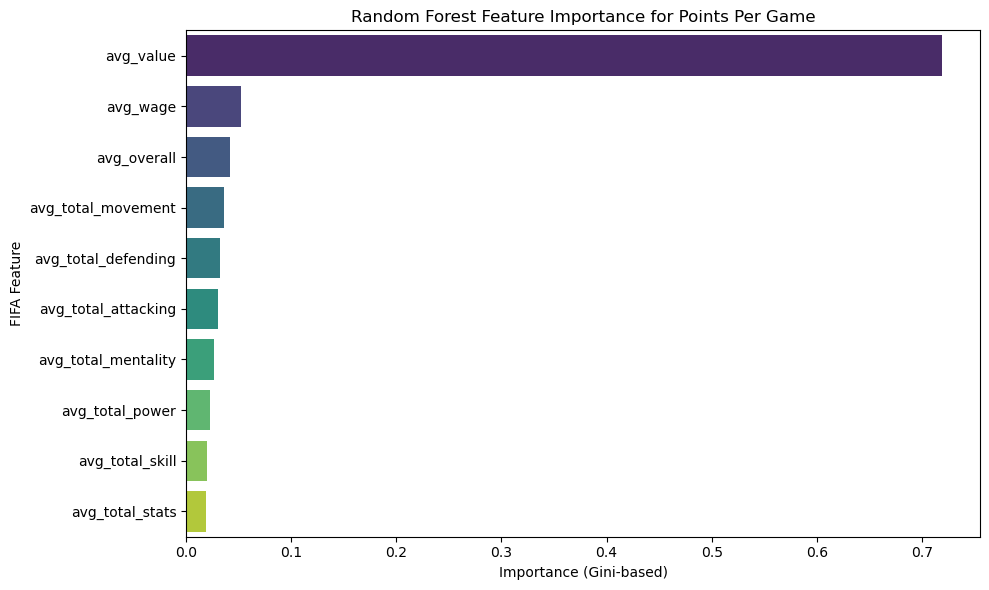

In [58]:

X_rf = merged_df[fifa_cols]
y_rf = merged_df["points_per_game"]

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_rf, y_rf)

rf_importance = pd.DataFrame({
    "feature": fifa_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances (predicting points_per_game):")
print(rf_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=rf_importance, palette="viridis")
plt.xlabel("Importance (Gini-based)")
plt.ylabel("FIFA Feature")
plt.title("Random Forest Feature Importance for Points Per Game")
plt.tight_layout()
plt.show()


#### Research Question 2

In [59]:
edition_map = {
    2020: "FIFA 21",
    2021: "FIFA 22",
    2022: "FIFA 23",
    2023: "FIFA 24",
    2024: "FC 25",
}

merged_df["edition"] = merged_df["season"].map(edition_map)
df_edition = merged_df[merged_df["edition"].notna()].copy()

In [60]:
perf_cols = ["points_per_game", "win_rate", "normalized_rank", "goal_diff"]
fifa_col = "avg_overall"  
rows = []

for ed, grp in df_edition.groupby("edition"):
    row = {"edition": ed}
    for col in perf_cols:
        row[col] = grp[fifa_col].corr(grp[col])
    rows.append(row)

corr_by_edition = pd.DataFrame(rows).sort_values("edition")
print(corr_by_edition)

   edition  points_per_game  win_rate  normalized_rank  goal_diff
0    FC 25             0.77      0.77             0.75       0.75
1  FIFA 22             0.79      0.77             0.75       0.76
2  FIFA 23             0.69      0.72             0.68       0.68
3  FIFA 24             0.71      0.72             0.65       0.70


In [61]:
order = ["FIFA 22", "FIFA 23", "FIFA 24", "FC 25"]

corr_by_edition["edition"] = pd.Categorical(
    corr_by_edition["edition"], 
    categories=order,
    ordered=True
)

corr_by_edition = corr_by_edition.sort_values("edition")

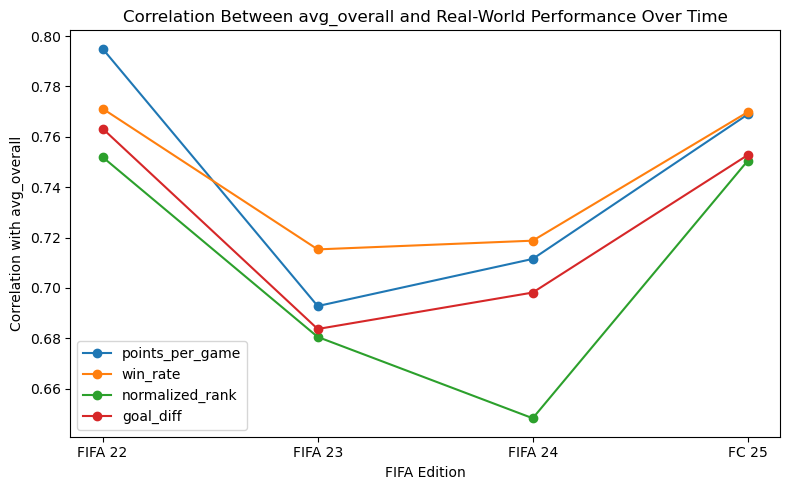

In [62]:
plt.figure(figsize=(8, 5))

for col in perf_cols:
    plt.plot(
        corr_by_edition["edition"],
        corr_by_edition[col],
        marker="o",
        label=col
    )

plt.xlabel("FIFA Edition")
plt.ylabel(f"Correlation with {fifa_col}")
plt.title(f"Correlation Between {fifa_col} and Real-World Performance Over Time")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:

fifa_predictors = ["avg_overall", "avg_value"] 

r2_rows = []

for ed, grp in df_edition.groupby("edition"):
    X = grp[fifa_predictors]
    X = sm.add_constant(X)
    y = grp["points_per_game"]

    model = sm.OLS(y, X).fit()
    r2_rows.append({"edition": ed, "R2_points_per_game": model.rsquared})

r2_by_edition = pd.DataFrame(r2_rows).sort_values("edition")
print(r2_by_edition)

   edition  R2_points_per_game
0    FC 25                0.63
1  FIFA 22                0.75
2  FIFA 23                0.50
3  FIFA 24                0.57


In [64]:
r2_by_edition["edition"] = pd.Categorical(
    r2_by_edition["edition"], 
    categories=order,
    ordered=True
)
r2_by_edition.sort_values("edition", inplace=True)

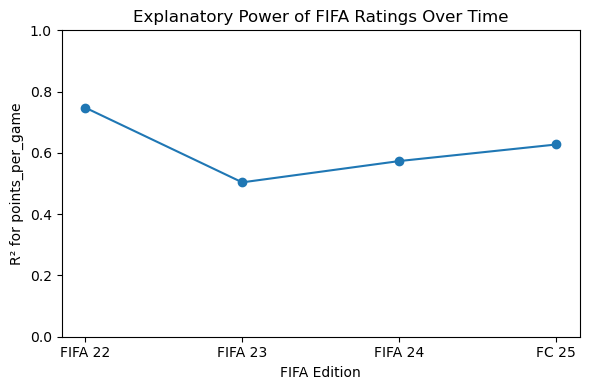

In [65]:
plt.figure(figsize=(6,4))
plt.plot(r2_by_edition["edition"], r2_by_edition["R2_points_per_game"], marker="o")
plt.ylim(0, 1)
plt.xlabel("FIFA Edition")
plt.ylabel("R² for points_per_game")
plt.title("Explanatory Power of FIFA Ratings Over Time")
plt.tight_layout()
plt.show()

### Hypothesis Test

Null Hypothesis (H₀): There is no significant difference in team performance metrics across seasons.  
Alternative Hypothesis (H₁): At least one season differs significantly in team performance metrics.


In [66]:

perf_metrics = ["points_per_game", "win_rate", "normalized_rank", "goal_diff"]

anova_results = []

for metric in perf_metrics:
    groups = [group[metric].dropna() for season, group in merged_df.groupby("season")]
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    sig = "Yes" if p_value < 0.05 else "No"
    result = "Reject H₀" if p_value < 0.05 else "Fail to Reject H₀"
    
    anova_results.append({
        "Performance Metric": metric.replace("_", " ").title(),
        "F-Statistic": round(f_stat, 4),
        "p-value": round(p_value, 4),
        "Significant (α=0.05)": sig,
        "Decision": result
    })

anova_df = pd.DataFrame(anova_results)


print(anova_df.to_string(index=False))



Performance Metric  F-Statistic  p-value Significant (α=0.05)          Decision
   Points Per Game         1.18     0.32                   No Fail to Reject H₀
          Win Rate         1.15     0.33                   No Fail to Reject H₀
   Normalized Rank         1.43     0.23                   No Fail to Reject H₀
         Goal Diff         1.32     0.27                   No Fail to Reject H₀


### Model Diagnostics

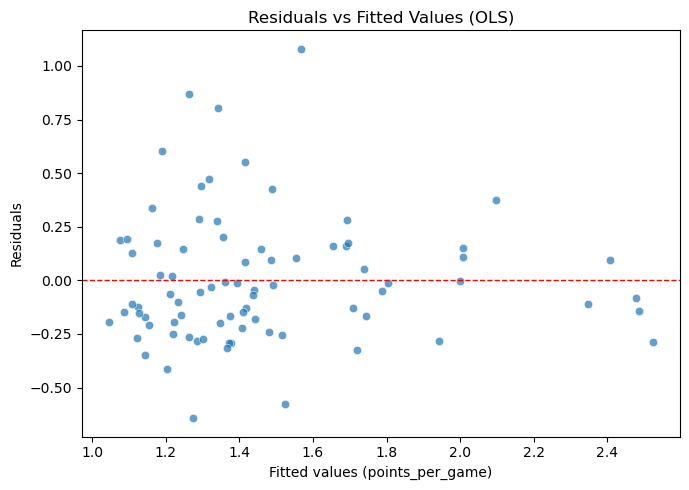

In [67]:

fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Fitted values (points_per_game)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (OLS)")
plt.tight_layout()
plt.show()

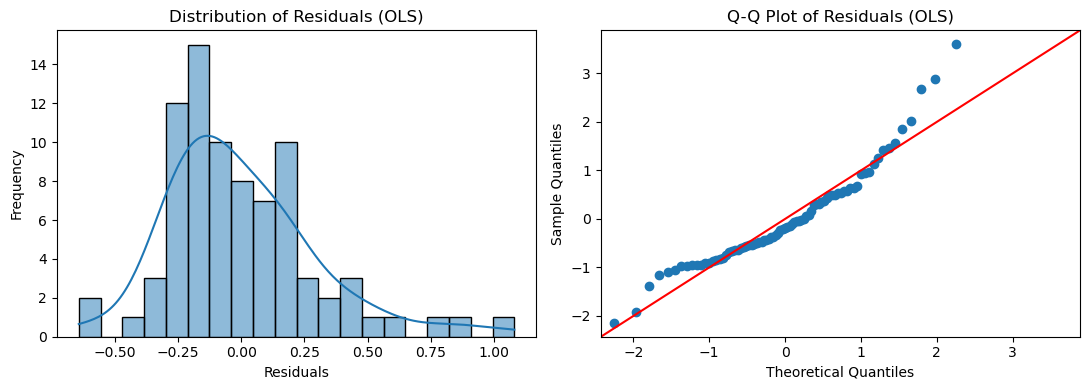

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(residuals, bins=20, kde=True, ax=axes[0])
axes[0].set_xlabel("Residuals")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Residuals (OLS)")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals (OLS)")

plt.tight_layout()
plt.show()

In [69]:

X_for_vif = sm.add_constant(merged_df[fifa_cols])

vif_data = pd.DataFrame({
    "feature": X_for_vif.columns,
    "VIF": [
        variance_inflation_factor(X_for_vif.values, i)
        for i in range(X_for_vif.shape[1])
    ]
})

vif_data

,feature,VIF
0,const,"3,038.54"
1,avg_overall,21.76
2,avg_value,8.76
3,avg_wage,5.54
4,avg_total_stats,238.95
5,avg_total_attacking,16.53
6,avg_total_skill,28.17
7,avg_total_movement,7.57
8,avg_total_power,14.09
9,avg_total_mentality,29.93


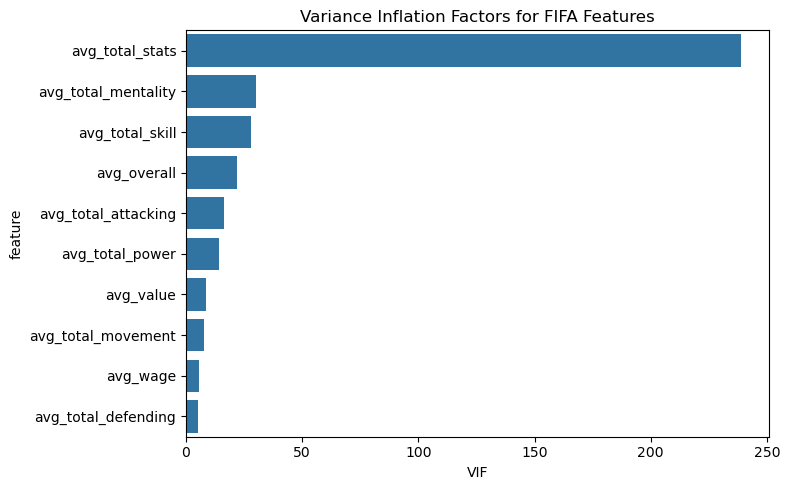

In [70]:
vif_plot = vif_data[vif_data["feature"] != "const"].copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=vif_plot.sort_values("VIF", ascending=False),
    x="VIF", y="feature"
)
plt.title("Variance Inflation Factors for FIFA Features")
plt.tight_layout()
plt.show()

In [71]:
X_rf = merged_df[fifa_cols]
y_rf = merged_df["points_per_game"]

X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

rf_diag = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)
rf_diag.fit(X_train, y_train)

y_pred_train = rf_diag.predict(X_train)
y_pred_test = rf_diag.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train RMSE: {rmse_train:.3f}, R²: {r2_train:.3f}")
print(f"Test  RMSE: {rmse_test:.3f}, R²: {r2_test:.3f}")

Train RMSE: 0.139, R²: 0.908
Test  RMSE: 0.264, R²: 0.631


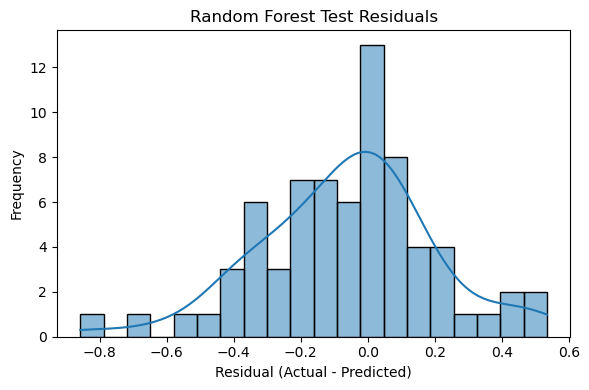

In [72]:
rf_residuals_test = y_test - y_pred_test

plt.figure(figsize=(6, 4))
sns.histplot(rf_residuals_test, bins=20, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Random Forest Test Residuals")
plt.tight_layout()
plt.show()

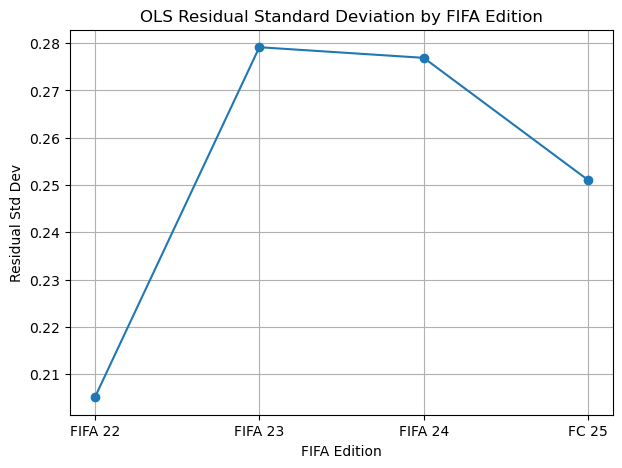

In [73]:
residual_stds = {}

for edition in merged_df['edition'].unique():
    subset = merged_df[merged_df['edition'] == edition]
    X_sub = sm.add_constant(subset[fifa_cols])
    y_sub = subset['points_per_game']
    model_sub = sm.OLS(y_sub, X_sub).fit()
    
    residual_stds[edition] = model_sub.resid.std()

plt.figure(figsize=(7,5))
plt.plot(list(residual_stds.keys()), list(residual_stds.values()), marker='o')
plt.title("OLS Residual Standard Deviation by FIFA Edition")
plt.xlabel("FIFA Edition")
plt.ylabel("Residual Std Dev")
plt.grid(True)
plt.show()

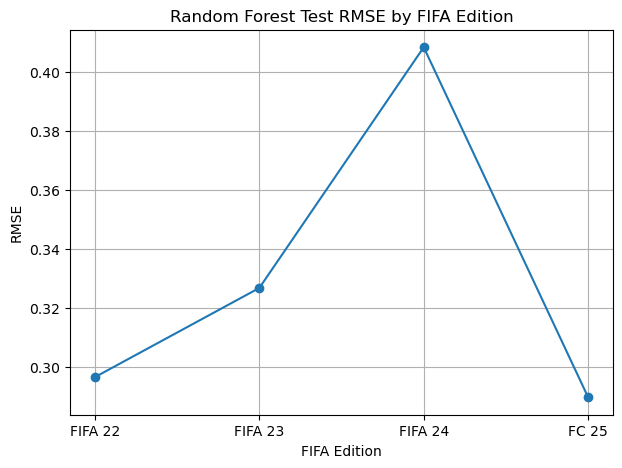

In [74]:
rf_rmse = {}

for edition in merged_df['edition'].unique():
    subset = merged_df[merged_df['edition'] == edition]
    X_sub = subset[fifa_cols]
    y_sub = subset['points_per_game']

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42
    )
    
    rf_sub = RandomForestRegressor(n_estimators=500, random_state=42)
    rf_sub.fit(X_train, y_train)
    preds = rf_sub.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    rf_rmse[edition] = rmse

plt.figure(figsize=(7,5))
plt.plot(list(rf_rmse.keys()), list(rf_rmse.values()), marker='o')
plt.title("Random Forest Test RMSE by FIFA Edition")
plt.xlabel("FIFA Edition")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()